# Crypt primitive fitting audit

This notebook audits already-exported `organograph_shape_v2` skeletons and crypt primitives. It does **not** rerun skeletonization or fitting. The current export can therefore remain a fixed baseline while a new fitting implementation is tested on only a small subset of organoids.

QC flags are diagnostic warnings, not biological parameters. They should be used for inspection and fit comparison, not encoded by the VAE. Branched organoids are excluded by default.

In [11]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from organograph.mesh.OrganoidMesh import OrganoidMesh
from organograph.plotting.skeletons import plot_mesh_with_skeleton_and_primitives
from organograph.skeleton import (
    CryptPrimitiveQCConfig,
    QC_FLAG_COLUMNS,
    discover_shape_exports,
    load_crypt_primitive_qc,
    load_shape_export_graph,
    load_shape_export_json,
    pair_crypt_primitive_qc,
)

plt.style.use("seaborn-v0_8-whitegrid")

## Configuration

Keep `BASELINE_EXPORT_ROOT` fixed. Set `CANDIDATE_EXPORT_ROOT` after exporting a new fit; it may contain the full dataset or only a development subset. Candidate comparisons automatically use only samples present in both exports.

In [12]:
DATA_ROOT = (PROJECT_ROOT.parent / "NicoleData").resolve()
BASELINE_EXPORT_ROOT = DATA_ROOT / "combined_skeleton_primitive_exports_v2"

# Point this at a complete or partial export after changing the fit.
CANDIDATE_EXPORT_ROOT = DATA_ROOT / "combined_skeleton_primitive_exports_fixed"

UNBRANCHED_ONLY = True
MAX_BASELINE_SAMPLES = None
MAX_CANDIDATE_SAMPLES = None

QC_CONFIG = CryptPrimitiveQCConfig(
    center_position_bounds=(0.05, 0.80),
    fixed_taper_position=0.85,
    min_center_taper_gap=0.05,
    position_tolerance=0.01,
    max_neck_to_body_ratio=2.0,
    max_distal_to_body_ratio=1.0,
    max_crypt_body_to_host_scale=0.75,
    min_length_to_host_scale=0.10,
)

N_RANKED_ORGANOIDS = 30
N_RENDERED_ORGANOIDS = 10
MANUAL_SAMPLE_KEYS = []  # e.g. ["20250929::day3p5::day3p5_A03_63"]

In [13]:
baseline_qc = load_crypt_primitive_qc(
    BASELINE_EXPORT_ROOT,
    config=QC_CONFIG,
    unbranched_only=UNBRANCHED_ONLY,
    max_samples=MAX_BASELINE_SAMPLES,
)

candidate_qc = pd.DataFrame()
if CANDIDATE_EXPORT_ROOT is not None:
    candidate_qc = load_crypt_primitive_qc(
        CANDIDATE_EXPORT_ROOT,
        config=QC_CONFIG,
        unbranched_only=UNBRANCHED_ONLY,
        max_samples=MAX_CANDIDATE_SAMPLES,
    )

def cohort_summary(table, name):
    return {
        "cohort": name,
        "organoids_with_crypts": table["sample_key"].nunique(),
        "crypts": len(table),
        "bulged": int((table["subtype"] == "bulged").sum()),
        "budded": int((table["subtype"] == "budded").sum()),
        "crypts_with_qc_flags": int(table["has_qc_flag"].sum()),
    }

summaries = [cohort_summary(baseline_qc, "baseline")]
if not candidate_qc.empty:
    summaries.append(cohort_summary(candidate_qc, "candidate"))
display(pd.DataFrame(summaries))

,cohort,organoids_with_crypts,crypts,bulged,budded,crypts_with_qc_flags
0,baseline,1143,2322,2099,223,1282
1,candidate,195,392,375,17,15


## Parameter distributions

When a candidate export is present, its distributions are compared with the matching baseline subset rather than the entire baseline. This avoids confounding a fitting change with a different sample composition. `r_distal` is the radius at the start of terminal closure, not the zero radius at the endpoint.

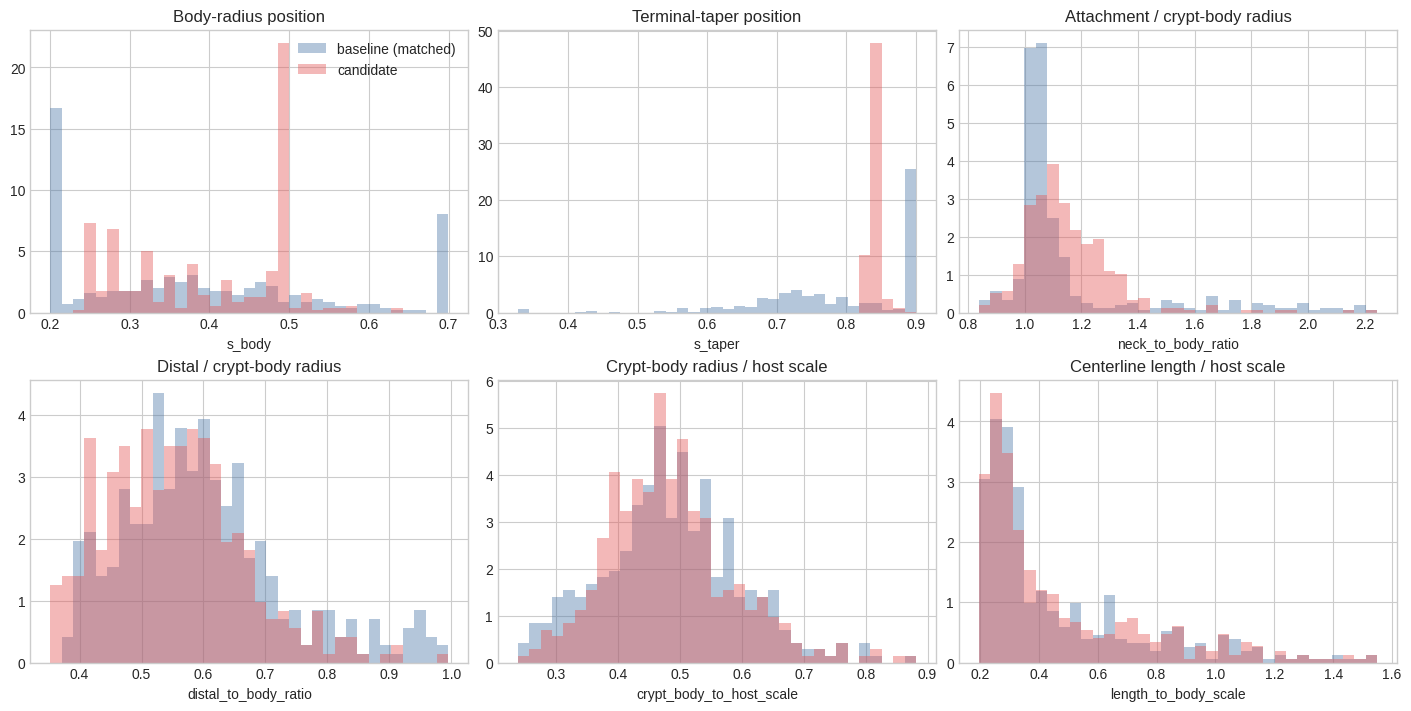

In [14]:
PARAMETER_PANELS = {
    "s_center": "Projected crypt-center position",
    "neck_to_body_ratio": "Attachment / crypt-body radius",
    "distal_to_body_ratio": "Distal / crypt-body radius",
    "crypt_body_to_host_scale": "Crypt-body radius / host scale",
    "length_to_body_scale": "Centerline length / host scale",
}

def matched_tables(baseline, candidate):
    if candidate.empty:
        return [("baseline (full)", baseline)]
    keys = set(candidate["sample_key"])
    matched = baseline[baseline["sample_key"].isin(keys)].copy()
    return [("baseline (matched)", matched), ("candidate", candidate)]

def plot_parameter_distributions(baseline, candidate):
    tables = matched_tables(baseline, candidate)
    colors = ["#4c78a8", "#e45756"]
    fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)
    for ax, (column, title) in zip(axes.ravel(), PARAMETER_PANELS.items()):
        combined = pd.concat([table[column] for _, table in tables], ignore_index=True)
        finite = combined[np.isfinite(combined)]
        if finite.empty:
            ax.set_visible(False)
            continue
        lo, hi = finite.quantile([0.005, 0.995])
        if hi <= lo:
            hi = lo + 1.0
        bins = np.linspace(lo, hi, 36)
        for (label, table), color in zip(tables, colors):
            values = table[column].to_numpy(float)
            values = values[np.isfinite(values)]
            ax.hist(values, bins=bins, density=True, alpha=0.42, color=color, label=label)
        ax.set_title(title)
        ax.set_xlabel(column)
    axes.ravel()[0].legend(frameon=False)
    return fig

display(plot_parameter_distributions(baseline_qc, candidate_qc))
plt.close()

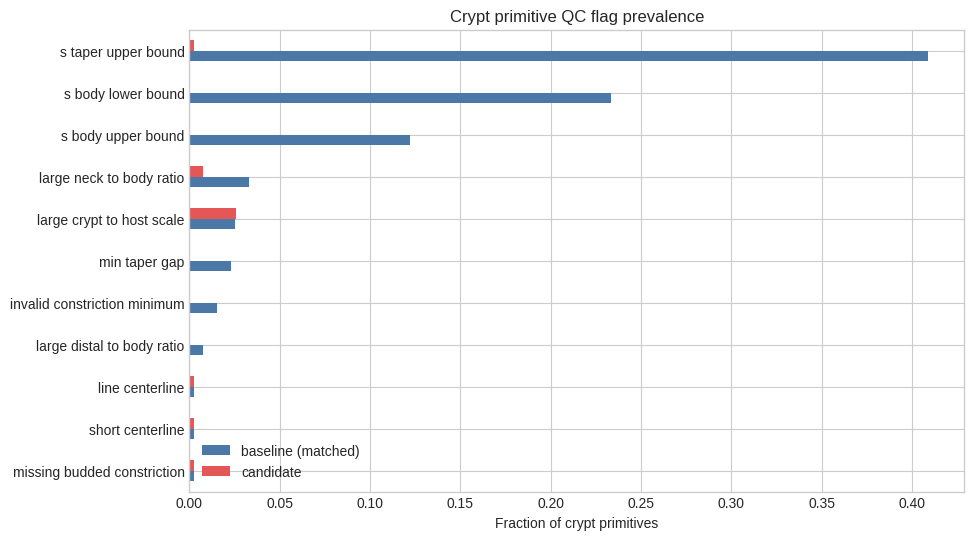

,baseline (matched),candidate
QC flag (%),,
s taper upper bound,40.86,0.26
s body lower bound,23.35,0.00
s body upper bound,12.18,0.00
large neck to body ratio,3.30,0.77
large crypt to host scale,2.54,2.55
min taper gap,2.28,0.00
invalid constriction minimum,1.52,0.00
large distal to body ratio,0.76,0.00
line centerline,0.25,0.26


subtype,budded,bulged
Baseline QC flag by subtype (%),,
s body lower bound,1.79,20.77
s body upper bound,4.93,13.86
s taper upper bound,66.82,37.64
min taper gap,8.07,3.05
missing budded constriction,0.45,0.00
invalid constriction minimum,28.70,0.00
large neck to body ratio,0.45,3.43
large distal to body ratio,3.14,1.24
large crypt to host scale,1.79,2.95


subtype,budded,bulged
Candidate QC flag by subtype (%),,
s body lower bound,0.00,0.00
s body upper bound,0.00,0.00
s taper upper bound,0.00,0.27
min taper gap,0.00,0.00
missing budded constriction,5.88,0.00
invalid constriction minimum,0.00,0.00
large neck to body ratio,0.00,0.80
large distal to body ratio,0.00,0.00
large crypt to host scale,0.00,2.67


In [15]:
def readable_flag(flag):
    return flag.removeprefix("flag_").replace("_", " ")

def plot_flag_prevalence(baseline, candidate):
    tables = matched_tables(baseline, candidate)
    rates = pd.DataFrame(
        {label: table[list(QC_FLAG_COLUMNS)].mean() for label, table in tables}
    )
    rates.index = [readable_flag(value) for value in rates.index]
    rates = rates.loc[rates.max(axis=1).sort_values().index]
    ax = rates.plot.barh(figsize=(10, 6), color=["#4c78a8", "#e45756"][:len(rates.columns)])
    ax.set_xlabel("Fraction of crypt primitives")
    ax.set_ylabel("")
    ax.set_title("Crypt primitive QC flag prevalence")
    ax.legend(frameon=False)
    return ax.figure, rates.sort_values(rates.columns[0], ascending=False)

flag_figure, flag_rates = plot_flag_prevalence(baseline_qc, candidate_qc)
display(flag_figure)
plt.close(flag_figure)
display((100 * flag_rates).round(2).rename_axis("QC flag (%)"))

baseline_subtype_rates = 100 * baseline_qc.groupby("subtype")[list(QC_FLAG_COLUMNS)].mean().T
baseline_subtype_rates.index = [readable_flag(value) for value in baseline_subtype_rates.index]
display(baseline_subtype_rates.round(2).rename_axis("Baseline QC flag by subtype (%)"))
if not candidate_qc.empty:
    candidate_subtype_rates = 100 * candidate_qc.groupby("subtype")[list(QC_FLAG_COLUMNS)].mean().T
    candidate_subtype_rates.index = [readable_flag(value) for value in candidate_subtype_rates.index]
    display(candidate_subtype_rates.round(2).rename_axis("Candidate QC flag by subtype (%)"))

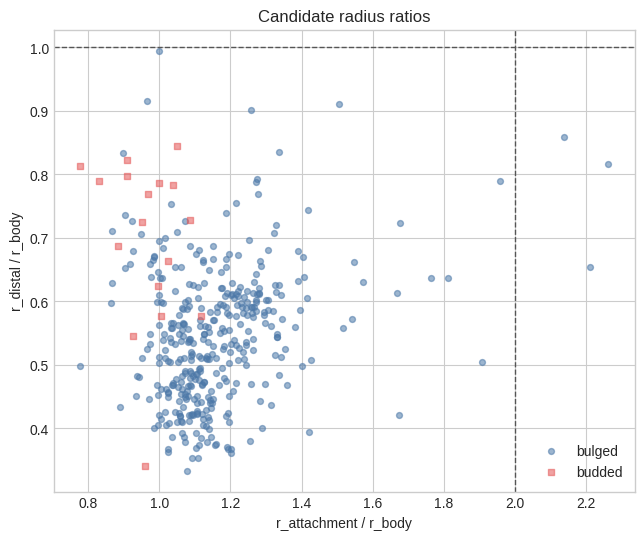

In [16]:
def plot_radius_ratio_scatter(table, title):
    fig, ax = plt.subplots(figsize=(7.5, 6))
    for subtype, color, marker in [("bulged", "#4c78a8", "o"), ("budded", "#e45756", "s")]:
        subset = table[table["subtype"] == subtype]
        ax.scatter(
            subset["neck_to_body_ratio"],
            subset["distal_to_body_ratio"],
            s=18, alpha=0.55, color=color, marker=marker, label=subtype,
        )
    ax.axvline(QC_CONFIG.max_neck_to_body_ratio, color="#555555", linestyle="--", linewidth=1)
    ax.axhline(QC_CONFIG.max_distal_to_body_ratio, color="#555555", linestyle="--", linewidth=1)
    ax.set_xlabel("r_attachment / r_body")
    ax.set_ylabel("r_distal / r_body")
    ax.set_title(title)
    ax.legend(frameon=False)
    return fig

scatter_source = candidate_qc if not candidate_qc.empty else baseline_qc
scatter_title = "Candidate radius ratios" if not candidate_qc.empty else "Baseline radius ratios"
display(plot_radius_ratio_scatter(scatter_source, scatter_title))
plt.close()

## Ranked problem organoids

Ranking prioritizes missing or non-minimal budded constrictions, followed by extreme radius ratios and scale, then bound saturation and fallbacks. It is deliberately a triage score rather than a biological validity score.

In [17]:
def rank_problem_organoids(table):
    flagged = table[table["has_qc_flag"]].copy()
    ranked = (
        flagged.groupby(["sample_key", "dataset", "timepoint", "label_uid"], dropna=False)
        .agg(
            qc_severity=("qc_severity", "sum"),
            flagged_crypts=("primitive_id", "size"),
            maximum_flags_on_one_crypt=("n_qc_flags", "max"),
            flags=("qc_flags", lambda values: "; ".join(sorted(set("; ".join(values).split("; "))))),
        )
        .reset_index()
        .sort_values(["qc_severity", "flagged_crypts"], ascending=False)
    )
    return ranked

ranked_organoids = rank_problem_organoids(baseline_qc)
problem_crypts = baseline_qc[baseline_qc["has_qc_flag"]].sort_values(
    ["qc_severity", "n_qc_flags"], ascending=False
)
display(ranked_organoids.head(N_RANKED_ORGANOIDS))
display(
    problem_crypts[[
        "sample_key", "primitive_id", "subtype", "qc_severity", "qc_flags",
        "s_center", "neck_to_body_ratio",
        "distal_to_body_ratio", "constriction_to_body_ratio",
        "crypt_body_to_host_scale",
    ]].head(2 * N_RANKED_ORGANOIDS)
)

,sample_key,dataset,timepoint,label_uid,qc_severity,flagged_crypts,maximum_flags_on_one_crypt,flags
414,20250929::day4p5-more::day4p5-more_C02_26,20250929,day4p5-more,day4p5-more_C02_26,10,4,3,large_crypt_to_host_scale; min_taper_gap; s_bo...
456,20250929::day4p5-more::day4p5-more_C03_120,20250929,day4p5-more,day4p5-more_C03_120,9,2,3,invalid_constriction_minimum; large_crypt_to_h...
470,20250929::day4p5-more::day4p5-more_C03_171,20250929,day4p5-more,day4p5-more_C03_171,9,2,3,invalid_constriction_minimum; s_body_lower_bou...
726,20251201::day4p5::day4p5_B02_35,20251201,day4p5,day4p5_B02_35,9,2,3,invalid_constriction_minimum; large_neck_to_bo...
236,20250929::day4::day4_A06_29,20250929,day4,day4_A06_29,8,4,2,invalid_constriction_minimum; s_body_upper_bou...
355,20250929::day4::day4_B02_92,20250929,day4,day4_B02_92,8,3,2,invalid_constriction_minimum; s_body_lower_bou...
86,20250929::day3p5::day3p5_A03_63,20250929,day3p5,day3p5_A03_63,8,2,3,large_neck_to_body_ratio; s_body_upper_bound; ...
177,20250929::day4::day4_A04_24,20250929,day4,day4_A04_24,8,2,3,large_crypt_to_host_scale; large_distal_to_bod...
454,20250929::day4p5-more::day4p5-more_C03_111,20250929,day4p5-more,day4p5-more_C03_111,8,2,3,invalid_constriction_minimum; large_neck_to_bo...
480,20250929::day4p5-more::day4p5-more_C03_35,20250929,day4p5-more,day4p5-more_C03_35,8,2,4,large_distal_to_body_ratio; large_neck_to_body...


,sample_key,primitive_id,subtype,qc_severity,qc_flags,s_body,s_taper,neck_to_body_ratio,distal_to_body_ratio,constriction_to_body_ratio,crypt_body_to_host_scale
1457,20250929::day4p5-more::day4p5-more_C03_120,crypt_0_path_0,budded,7,invalid_constriction_minimum; large_neck_to_bo...,0.517589,0.754225,2.022639,1.182703,1.513901,0.433439
764,20250929::day4::day4_B01_12,crypt_1_path_0,bulged,6,s_body_upper_bound; s_taper_upper_bound; large...,0.699832,0.899966,2.550118,1.043911,NaN,0.299718
1526,20250929::day4p5-more::day4p5-more_C03_30,crypt_0_path_0,bulged,6,s_body_upper_bound; s_taper_upper_bound; large...,0.699832,0.899966,2.707782,1.155265,NaN,0.256819
1534,20250929::day4p5-more::day4p5-more_C03_35,crypt_1_path_0,bulged,6,s_body_upper_bound; s_taper_upper_bound; large...,0.699832,0.899966,2.572779,1.139180,NaN,0.241367
2028,20251201::day4p5::day4p5_B03_106,crypt_0_path_0,bulged,6,s_body_upper_bound; s_taper_upper_bound; large...,0.699832,0.899966,2.379883,1.084394,NaN,0.222070
549,20250929::day4::day4_A05_21,crypt_0_path_0,budded,6,s_body_upper_bound; missing_budded_constrictio...,0.699832,0.834311,0.893850,0.241937,NaN,0.754825
493,20250929::day4::day4_A04_24,crypt_1_path_0,bulged,5,s_taper_upper_bound; large_neck_to_body_ratio;...,0.603599,0.895376,2.018171,1.980314,NaN,0.668561
635,20250929::day4::day4_A06_13,crypt_0_path_0,bulged,5,s_taper_upper_bound; large_neck_to_body_ratio;...,0.477249,0.899892,2.100898,1.003499,NaN,0.282915
828,20250929::day4::day4_B01_67,crypt_1_path_0,bulged,5,s_taper_upper_bound; large_neck_to_body_ratio;...,0.642049,0.899947,2.424284,1.094776,NaN,0.196128
856,20250929::day4::day4_B01_89,crypt_0_path_0,budded,5,s_body_upper_bound; s_taper_upper_bound; inval...,0.699832,0.899966,1.640370,0.853908,1.683028,0.365437


## Paired baseline-versus-candidate comparison

Pairing uses `sample_key + primitive_id`. A low pairing rate should be investigated before interpreting parameter changes because it may indicate changed topology or crypt identities rather than only changed fitting.

Paired 360 / 392 candidate crypts (91.8%).


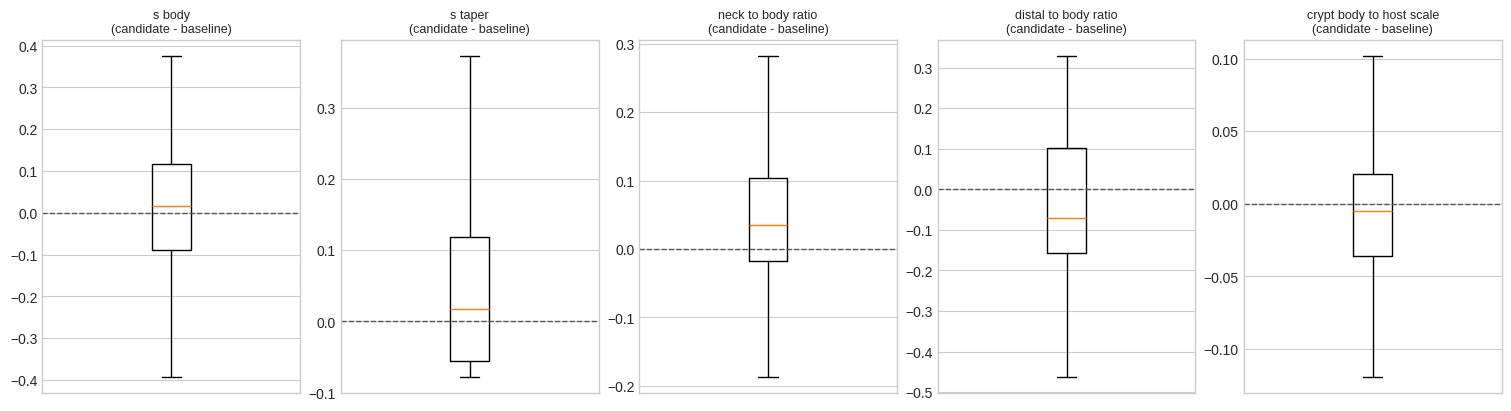

,baseline,candidate,change
Paired QC rate (%),,,
s body lower bound,24.44,0.00,-24.44
s body upper bound,12.50,0.00,-12.50
s taper upper bound,42.78,0.00,-42.78
min taper gap,2.50,0.00,-2.50
missing budded constriction,0.28,0.28,0.00
invalid constriction minimum,1.67,0.00,-1.67
large neck to body ratio,2.78,0.28,-2.50
large distal to body ratio,0.00,0.00,0.00
large crypt to host scale,2.50,2.50,0.00


In [18]:
paired_qc = pair_crypt_primitive_qc(baseline_qc, candidate_qc)
if paired_qc.empty:
    display(HTML("<p>Set <code>CANDIDATE_EXPORT_ROOT</code> to enable paired comparisons.</p>"))
else:
    candidate_crypts = len(candidate_qc)
    print(
        f"Paired {len(paired_qc):,} / {candidate_crypts:,} candidate crypts "
        f"({len(paired_qc) / max(candidate_crypts, 1):.1%})."
    )
    delta_columns = [
        "s_center", "neck_to_body_ratio",
        "distal_to_body_ratio", "crypt_body_to_host_scale",
    ]
    deltas = pd.DataFrame({
        column: paired_qc[f"{column}_candidate"] - paired_qc[f"{column}_baseline"]
        for column in delta_columns
    })
    fig, axes = plt.subplots(1, len(delta_columns), figsize=(15, 4), constrained_layout=True)
    for ax, column in zip(axes, delta_columns):
        values = deltas[column].replace([np.inf, -np.inf], np.nan).dropna()
        ax.boxplot(values, vert=True, showfliers=False)
        ax.axhline(0.0, color="#555555", linestyle="--", linewidth=1)
        ax.set_xticks([])
        ax.set_title(column.replace("_", " ") + "\n(candidate - baseline)", fontsize=9)
    display(fig)
    plt.close(fig)

    paired_flag_rates = pd.DataFrame({
        "baseline": {flag: paired_qc[f"{flag}_baseline"].mean() for flag in QC_FLAG_COLUMNS},
        "candidate": {flag: paired_qc[f"{flag}_candidate"].mean() for flag in QC_FLAG_COLUMNS},
    })
    paired_flag_rates["change"] = paired_flag_rates["candidate"] - paired_flag_rates["baseline"]
    paired_flag_rates.index = [readable_flag(value) for value in paired_flag_rates.index]
    display((100 * paired_flag_rates).round(2).rename_axis("Paired QC rate (%)"))

## Candidate fit diagnostics

New exports may contain a separate `quality.json` sidecar. These optimizer, support, and residual fields remain outside the VAE input. The old baseline intentionally shows missing values here.

,optimizer_success_rate,median_optimizer_nfev,median_fit_rmse,median_profile_observation_rmse,median_supported_bins,distal_constraint_rate,constriction_constraint_rate
0,0.9974,6.0,0.2894,0.084,20.0,0.0026,0.0204


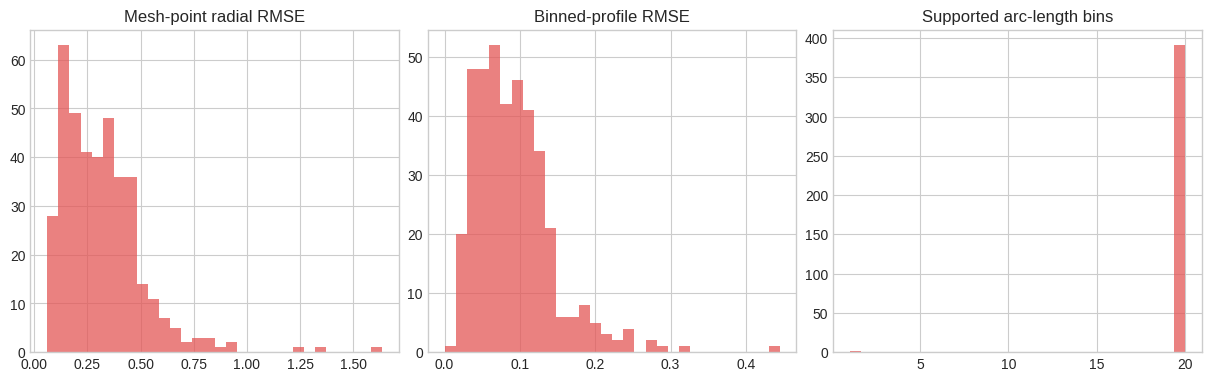

In [19]:
quality_source = candidate_qc if not candidate_qc.empty else baseline_qc
quality_available = quality_source["optimizer_success"].notna().any()
if not quality_available:
    display(HTML("<p>No <code>quality.json</code> diagnostics are available for this cohort.</p>"))
else:
    diagnostic_summary = pd.DataFrame({
        "optimizer_success_rate": [quality_source["optimizer_success"].astype(float).mean()],
        "median_optimizer_nfev": [quality_source["optimizer_nfev"].median()],
        "median_fit_rmse": [quality_source["fit_rmse"].median()],
        "median_profile_observation_rmse": [quality_source["profile_observation_rmse"].median()],
        "median_supported_bins": [quality_source["n_supported_bins"].median()],
        "distal_constraint_rate": [quality_source["distal_constraint_active"].astype(float).mean()],
        "constriction_constraint_rate": [quality_source["constriction_constraint_active"].astype(float).mean()],
    })
    display(diagnostic_summary.round(4))
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.7), constrained_layout=True)
    for ax, column, title in zip(
        axes,
        ["fit_rmse", "profile_observation_rmse", "n_supported_bins"],
        ["Mesh-point radial RMSE", "Binned-profile RMSE", "Supported arc-length bins"],
    ):
        values = pd.to_numeric(quality_source[column], errors="coerce").dropna()
        ax.hist(values, bins=30, color="#e45756", alpha=0.75)
        ax.set_title(title)
    display(fig)
    plt.close(fig)

## Visual inspection of flagged fits

The graph is transformed back to source-mesh coordinates, so no fitting is performed here. The source mesh may differ slightly from the spectrally smoothed fitting mesh, but positions, scales, rotations, skeleton topology, and primitive geometry are restored consistently. Use `MANUAL_SAMPLE_KEYS` to inspect known examples or leave it empty to render the highest-ranked organoids.

In [ ]:
def export_sample_key(payload):
    sample = payload.get("sample") or {}
    return "::".join(str(sample.get(key, "")) for key in ("dataset", "timepoint", "label_uid"))


candidate_shape_paths = {}
if CANDIDATE_EXPORT_ROOT is not None:
    for candidate_path in discover_shape_exports(CANDIDATE_EXPORT_ROOT):
        candidate_payload = load_shape_export_json(candidate_path)
        candidate_shape_paths[export_sample_key(candidate_payload)] = candidate_path


def exported_fit_figure(shape_path, *, title):
    shape_path = Path(shape_path)
    payload = load_shape_export_json(shape_path)
    mesh = OrganoidMesh(str(payload["sample"]["mesh_path"]))
    graph = load_shape_export_graph(shape_path, coordinate_system="source")
    figure = plot_mesh_with_skeleton_and_primitives(
        mesh.v, mesh.f, graph, backend="plotly",
        mesh_alpha=0.12, primitive_alpha=0.34, show_node_labels=False,
    )
    figure.update_layout(title=title, showlegend=False)
    return figure


def plot_exported_fit_comparison(sample_key):
    baseline_rows = baseline_qc[baseline_qc["sample_key"] == sample_key]
    if baseline_rows.empty:
        print(f"Baseline sample not found: {sample_key}")
        return

    candidate_rows = candidate_qc[candidate_qc["sample_key"] == sample_key]
    comparison_records = baseline_rows.assign(cohort="baseline").to_dict("records")
    comparison_records.extend(candidate_rows.assign(cohort="candidate").to_dict("records"))
    comparison_rows = pd.DataFrame.from_records(comparison_records)

    display(HTML(f"<h3>{sample_key}</h3>"))
    display(comparison_rows[[
        "cohort", "primitive_id", "subtype", "qc_severity", "qc_flags",
        "neck_to_body_ratio", "distal_to_body_ratio",
        "constriction_to_body_ratio", "s_center",
    ]])
    display(exported_fit_figure(
        Path(baseline_rows.iloc[0]["shape_path"]),
        title=f"{sample_key}: baseline",
    ))
    candidate_path = candidate_shape_paths.get(sample_key)
    if candidate_path is not None:
        display(exported_fit_figure(
            candidate_path,
            title=f"{sample_key}: candidate",
        ))


selected_keys = list(MANUAL_SAMPLE_KEYS)
if not selected_keys:
    selected_keys = ranked_organoids["sample_key"].head(N_RENDERED_ORGANOIDS).tolist()
for selected_key in selected_keys:
    plot_exported_fit_comparison(selected_key)

## Interpreting a fitting experiment

A useful fitting change should reduce invalid constrictions, extreme ratios, fallback frequency, and position-bound accumulation on the **paired subset**, without creating large systematic parameter shifts or visibly worse mesh agreement. A reduced QC rate alone is not sufficient if it is achieved by hard clipping every crypt to the same shape.

The compact baseline export intentionally contains no optimizer or residual diagnostics. Future candidate exports may add a separate QC sidecar, but the reconstructive `shape.json` should remain minimal for VAE ingestion.